In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import os

import scipy.stats
from tqdm import tqdm

from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
import itertools
import time

import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F


In [32]:
args = {}

# Training params
args['batch_size'] = 32*2

args['epochs'] = 50*10*4
args['start_epoch'] = 0

# For optimizer
args['lr'] = 1e-5 # LR for B-SNN params
args['sigma_true'] = 1e-5
args['sigma_pred'] = 1.45e-4

args['device'] =  torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

In [35]:
torch.cuda.empty_cache()

In [33]:
# Load planet_ids
train_adc_info = pd.read_csv('train_adc_info.csv',
                           index_col='planet_id')
# Load sensor data
train_data= np.load('data_train_clean.npy')

In [34]:
class CustomDataset(Dataset):
    def __init__(self, data_train, indices, path_labels):
        """
        Args:
            data_train (np.array): Array of shape (673, 187, 282, 32).
            indices (np.array): Array of indices corresponding to the rows in df_labels.
            path_labels (str): Path to the CSV file containing labels.
        """
        self.data_train = torch.tensor(data_train)  # Convert the data to a tensor
        self.data_indices = torch.tensor(indices).long()  # Convert indices to tensor
        self.df_labels = pd.read_csv(path_labels)  # Load df_labels as a pandas DataFrame
        
    def __len__(self):
        # Return the total number of samples
        return len(self.data_indices)

    def __getitem__(self, idx):
        # Get the index from data_indices
        index = self.data_indices[idx].item()  # Convert tensor to Python scalar
        
        # Select the data_train sample corresponding to the index
        data_sample = self.data_train[idx]  # Directly access the data without cloning

        # Select the corresponding label row where the first column matches the index
        label_row = self.df_labels[self.df_labels.iloc[:, 0] == index].iloc[0].values[1:]  # Exclude the first column (index)

        # Convert label_row to a tensor
        label = torch.tensor(label_row).float()

        return data_sample, label

# Example usage
path_ground = 'train_labels.csv'

# Assuming 'train' and 'train_adc_info' are pre-loaded variables containing the training data and indices.
# For example, train could be an array of shape (673, 187, 282, 32), and train_adc_info.index gives the indices.
custom_dataset = CustomDataset(train_data, train_adc_info.index, path_ground)

# Create a DataLoader to iterate over the dataset
dataloader = DataLoader(custom_dataset, batch_size=args['batch_size'], shuffle=True)  # Pass 'custom_dataset' here

# Iterate through the dataset
for batch_data, batch_labels in dataloader:
    print("Batch Data Shape:", batch_data.shape)  # Should be (batch_size, 187, 282, 32)
    print("Batch Labels Shape:", batch_labels.shape)  # Should be (batch_size, 283)
    break


KeyboardInterrupt: 

In [ ]:
class SpectralConv_efficient_b0(nn.Module):
    def __init__(self):
        super(SpectralConv_efficient_b0, self).__init__()
        
        # Use EfficientNet (pretrained)
        self.model = models.efficientnet_b0(pretrained=True)
        
        # Adjust the first convolutional layer for 1-channel input instead of 3-channel RGB
        self.model.features[0][0] = nn.Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)

        # Adjust the final fully connected layer to the desired output size
        self.model.classifier[1] = nn.Linear(in_features=1280, out_features=283, bias=True)

    def forward(self, x):
        # Apply convolutional layers and fully connected layers
        x = self.model(x)
        
        # Apply a Sigmoid activation after conv layers
        x = torch.sigmoid(x)
        
        return x

In [ ]:
class SpectralConv_efficient_b3(nn.Module):
    def __init__(self):
        super(SpectralConv_efficient_b3, self).__init__()
        
        # Use EfficientNet-B3 (pretrained)
        self.model = models.efficientnet_b3(pretrained=True)
        
        # Adjust the first convolutional layer for 1-channel input instead of 3-channel RGB
        self.model.features[0][0] = nn.Conv2d(1, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)

        # Adjust the final fully connected layer to the desired output size
        self.model.classifier[1] = nn.Linear(in_features=1536, out_features=283, bias=True)

    def forward(self, x):
        # Apply convolutional layers and fully connected layers
        x = self.model(x)
        
        # Apply a Sigmoid activation after conv layers
        x = torch.sigmoid(x)
        
        return x

In [ ]:
class SpectralConv_resnet(nn.Module):
    def __init__(self):
        super(SpectralConv_resnet, self).__init__()
        
        self.model = models.resnet50(pretrained=True)
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.model.fc = nn.Linear(in_features=2048, out_features=283, bias=True)

    
    def forward(self, x):
        # Apply convolutional layer
        x = self.model(x)
        
        # Apply a Sigmoid activation after conv1
        x = torch.sigmoid(x)
        
        return x

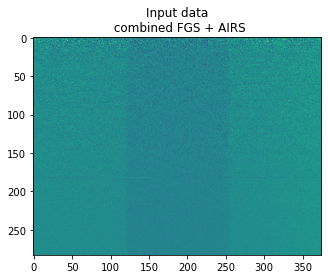

In [ ]:
plt.imshow(batch_data[0,:,:].T)
plt.title('Input data\n combined FGS + AIRS')
plt.show()

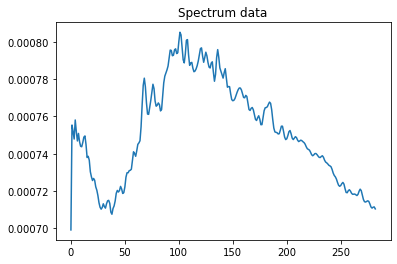

In [ ]:
plt.plot(batch_labels[1].T)
plt.title("Spectrum data")
plt.show()

In [ ]:
class ParticipantVisibleError(Exception):
    pass

class ArielLoss(nn.Module):
    def __init__(self, naive_mean, naive_sigma, sigma_true):
        super(ArielLoss, self).__init__()
        self.naive_mean = naive_mean
        self.naive_sigma = naive_sigma
        self.sigma_true = sigma_true

    def forward(self, solution, submission):
        '''
        This is a Gaussian Log Likelihood based loss function. For a submission, which contains the predicted mean (x_hat) and variance (x_hat_std),
        we calculate the Gaussian Log-likelihood (GLL) value compared to the provided ground truth (x). We treat each pair of x_hat,
        x_hat_std as a 1D gaussian, meaning there will be 283 1D gaussian distributions, hence 283 values for each test spectrum,
        the GLL value for one spectrum is the sum of all of them.

        Inputs:
            - solution: Ground Truth spectra (from test set)
                - shape: (nsamples, n_wavelengths)
            - submission: Predicted spectra and errors (from participants)
                - shape: (nsamples, n_wavelengths*2)
        '''
        if torch.any(submission < 0):
            raise ParticipantVisibleError('Negative values in the submission')

        # n_wavelengths = 283

        # Predicted mean and standard deviation
        y_pred = submission
        # Set a non-zero minimum sigma pred to prevent division by zero errors
        sigma_pred = torch.ones_like(y_pred)*args['sigma_pred'] #torch.clamp(submission[:, n_wavelengths:], min=1e-15)
        y_true = solution

        # Gaussian log-likelihood calculations
        GLL_pred = torch.sum(-0.5 * ((y_true - y_pred) / sigma_pred)**2 - torch.log(sigma_pred) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))
        GLL_true = torch.sum(-0.5 * ((y_true - y_true) / (self.sigma_true * torch.ones_like(y_true)))**2 - torch.log(self.sigma_true * torch.ones_like(y_true)) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))
        GLL_mean = torch.sum(-0.5 * ((y_true - self.naive_mean * torch.ones_like(y_true)) / (self.naive_sigma * torch.ones_like(y_true)))**2 - torch.log(self.naive_sigma * torch.ones_like(y_true)) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))

        # Score calculation
        submit_score = (GLL_pred - GLL_mean) / (GLL_true - GLL_mean)
        # submit_score = torch.clamp(submit_score, 0.0, 1.0)

        return -submit_score  # Return negative score as loss (since lower loss is better for training)


In [ ]:
class ParticipantVisibleError(Exception):
    pass
def ariel_score(
        solution,
        submission,
        naive_mean,
        naive_sigma,
        sigma_true
    ):
    '''
    This is a Gaussian Log Likelihood based metric. For a submission, which contains the predicted mean (x_hat) and variance (x_hat_std),
    we calculate the Gaussian Log-likelihood (GLL) value to the provided ground truth (x). We treat each pair of x_hat,
    x_hat_std as a 1D gaussian, meaning there will be 283 1D gaussian distributions, hence 283 values for each test spectrum,
    the GLL value for one spectrum is the sum of all of them.

    Inputs:
        - solution: Ground Truth spectra (from test set)
            - shape: (nsamples, n_wavelengths)
        - submission: Predicted spectra and errors (from participants)
            - shape: (nsamples, n_wavelengths*2)
        naive_mean: (float) mean from the train set.
        naive_sigma: (float) standard deviation from the train set.
        sigma_true: (float) essentially sets the scale of the outputs.
    '''

    if submission.min() < 0:
        raise ParticipantVisibleError('Negative values in the submission')

    n_wavelengths = 283

    y_pred = submission[:, :n_wavelengths]
    # Set a non-zero minimum sigma pred to prevent division by zero errors.
    sigma_pred = np.clip(submission[:, n_wavelengths:], a_min=10**-15, a_max=None)
    y_true = solution

    GLL_pred = np.sum(scipy.stats.norm.logpdf(y_true, loc=y_pred, scale=sigma_pred))
    GLL_true = np.sum(scipy.stats.norm.logpdf(y_true, loc=y_true, scale=sigma_true * np.ones_like(y_true)))
    GLL_mean = np.sum(scipy.stats.norm.logpdf(y_true, loc=naive_mean * np.ones_like(y_true), scale=naive_sigma * np.ones_like(y_true)))

    #print(GLL_pred, GLL_true, GLL_mean)
    submit_score = (GLL_pred - GLL_mean)/(GLL_true - GLL_mean)
    return submit_score #float(np.clip(submit_score, 0.0, 1.0))

In [ ]:
# # Load best model weights from checkpoint file
# pre_trained_epoch_num = 1000
# weights_checkpoint = f'checkpoint_efficient_phase_image_{pre_trained_epoch_num}.pth'

# scoring_SpecTrans  = SpectralConv_efficient()

# scoring_SpecTrans = scoring_SpecTrans.to(args['device'])
# # Load the state dict
# state_dict = torch.load(weights_checkpoint, map_location=args['device'])


# # Load the modified state dict into the model
# scoring_SpecTrans.load_state_dict(state_dict)
# scoring_SpecTrans.eval()

In [ ]:
# args['start_epoch'] = pre_trained_epoch_num

In [ ]:
naive_mean = 0
naive_std = 0
count = 0

for train_batch_idx, (img, y_true) in enumerate(dataloader):

    naive_mean += y_true.mean()
    naive_std += y_true.std()

    count += 1

naive_mean /= count
naive_std /= count
print('Naive Mean: {}'.format(naive_mean))
print('Naive std: {}'.format(naive_std))

Naive Mean: 0.0025377387646585703
Naive std: 0.0017035112250596285


In [ ]:
# Assuming SpectralTransformer and GLLLoss are already defined
specTrans = SpectralConv_efficient_b0()
specTrans.to(args['device'])
specTrans.train()

# Optimizer with a smaller learning rate
optimizer = optim.Adam(specTrans.parameters(), lr=args['lr'], betas=(0.9, 0.999), eps=1e-08)

# Use the custom lr scheduler

# criterion =  nn.MSELoss()
# Use the custom lr scheduler

# Quantile loss for two quantiles: 0.1 and 0.9
# quantile_loss_fn = QuantileLoss(quantiles=[0.1, 0.9])

# Training loop
start_time = time.time()

loss_train_arr = []
loss_valid_arr = []

loss_min = np.inf
acc_max = -np.inf


for epoch in range(args['start_epoch'], args['epochs']):
    

    # Calculate the current learning rate
    # current_lr = lrfn(epoch, num_warmup_steps=N_WARMUP_EPOCHS, lr_max=LR_MAX, num_cycles=0.50)
    #lrfn(current_step, num_warmup_steps, lr_max, num_cycles=0.50, num_training_steps=N_EPOCHS)

    train_acc = 0
    val_acc = 0
    loss_train = 0
    loss_valid = 0
    train_samples = 0
    val_samples = 0
    running_train_loss = 0
    running_eval_loss = 0


        
    for train_batch_idx, (img, y_true) in enumerate(dataloader):

        # Clear gradients for the optimizer before backward pass
        optimizer.zero_grad()
        
        
        img = img.to(torch.float32).to(args['device'])
        y_true = y_true.to(torch.float32).to(args['device'])
    

        # Forward pass
        y_pred = specTrans(img.unsqueeze(1)) # 283 dimensional
       
        
        train_loss_step = ArielLoss(naive_mean=naive_mean, naive_sigma=naive_std, sigma_true=args['sigma_true'])(        
            y_true,
            y_pred)
        
        # Backward pass on the loss, not the score
        train_loss_step.backward()


        # Update the weights
        optimizer.step()
    
        print("Train loss: {}".format(float(train_loss_step)))

        # # If you want to accumulate training loss across the epoch
       
        lr_th_print = optimizer.param_groups[0]["lr"]
        print("LR: {:9f}".format(lr_th_print))

    # Print the accumulated loss per epoch (optional)
    print(f'Epoch {epoch} finished')

    if epoch % 50 == 0:

        chckpt_file_path = 'checkpoint_resnet_phase_image_{}.pth'.format(epoch)
        torch.save(specTrans.state_dict(), chckpt_file_path)

    # You can also save checkpoints and track validation loss/accuracy here if needed

end_time = time.time()
print('Total training time: {:.4f} seconds'.format(end_time - start_time))


/Users/aditya/opt/anaconda3/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/aditya/opt/anaconda3/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


KeyboardInterrupt: 

In [ ]:
# torch.cuda.empty_cache()

In [ ]:
# Load best model weights from checkpoint file
weights_checkpoint = 'checkpoint_efficient_phase_image_100.pth'

scoring_SpecTrans  = SpectralConv_efficient()

scoring_SpecTrans = scoring_SpecTrans.to(args['device'])
# Load the state dict
state_dict = torch.load(weights_checkpoint, map_location=args['device'])


# Load the modified state dict into the model
scoring_SpecTrans.load_state_dict(state_dict)
scoring_SpecTrans.eval()

In [ ]:
# Iterate through the dataset
metric_cum = 0
count = 0
for batch_data, batch_labels in dataloader:

    scoring_SpecTrans.eval()

    output = scoring_SpecTrans(batch_data.to(torch.float32).to(args['device']).unsqueeze(1)).view(-1, 283, 2)

    pred_batch = output[:,:,0].cpu().detach().numpy()
    sigmas =  output[:,:,1].cpu().detach().numpy()#np.sqrt(1/(2*np.pi))*np.ones_like(pred_batch)

    metric = ariel_score(        
            batch_labels,
            np.concatenate([pred_batch.clip(0), sigmas.clip(0)], axis=1), 
            batch_data.mean(),
            batch_data.std(),
            sigma_true=1e-5)
            
    count += 1
    metric_cum += metric
    print(metric)

metric_cum /= count
metric_cum
